# Module 4 — Notebook 2: Customer Segmentation Modeling

This notebook uses `customer_features.csv` produced by Notebook 1 to build the customer segmentation layer.

## Modeling logic

1. **RFM segmentation** — value / lifecycle baseline.
2. **K-Means clustering** — main behavioral ML segmentation.
3. **Hierarchical clustering** — validation and explainability layer.
4. **Hybrid RFM + behavioral segmentation** — final business-actionable customer segments.

Plots are integrated inside each section so the notebook can be used directly for the report.

## 0. Setup

In [28]:
import os
import json
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import linkage, dendrogram

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

RANDOM_STATE = 42

INPUT_DIR = '../Module 4'
FEATURES_PATH = '../Module 4/customer_features.csv'

OUTPUT_DIR = '../Module 4'
MODEL_DIR = '../Module 4/models'
FIGURE_DIR = '../Module 4/figures'
REPORT_DIR = '../Module 4'

for d in [OUTPUT_DIR, MODEL_DIR, FIGURE_DIR, REPORT_DIR]:
    os.makedirs(d, exist_ok=True)

def save_current_figure(filename, dpi=160):
    path = os.path.join(FIGURE_DIR, filename)
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print("Saved:", path)

print("Input file:", FEATURES_PATH)
print("Output directory:", OUTPUT_DIR)
print("Model directory:", MODEL_DIR)
print("Figure directory:", FIGURE_DIR)

Input file: ../Module 4/customer_features.csv
Output directory: ../Module 4
Model directory: ../Module 4/models
Figure directory: ../Module 4/figures


## 1. Load customer feature matrix

In [29]:
customer_features = pd.read_csv(FEATURES_PATH)

print("Customer feature matrix shape:", customer_features.shape)
print("Unique customers:", customer_features["customer_id"].nunique())

display(customer_features.head())
display(customer_features.dtypes.value_counts())

Customer feature matrix shape: (10001, 78)
Unique customers: 10001


,customer_id,profile_transaction_match,archetype,price_tier,time_preference,day_preference,basket_size_bias,preferred_sections,preferred_categories,expected_visits,actual_visits,visit_gap,visit_ratio,under_engaged_flag,last_order_date,first_order_date,frequency,monetary,recency,customer_tenure_days,monetary_per_order,R_score,F_score,M_score,rfm_score,rfm_code,total_orders,avg_order_value,median_order_value,max_order_value,avg_basket_size,median_basket_size,avg_unique_items_per_order,avg_categories_per_order,avg_item_price,avg_discount_pct,discount_order_rate,total_discount_amount_est,payment_share_card,payment_share_cash,payment_share_mobile,preferred_payment_method,avg_order_hour,std_order_hour,weekend_order_rate,dow_share_friday,dow_share_monday,dow_share_saturday,dow_share_sunday,dow_share_thursday,dow_share_tuesday,dow_share_wednesday,meal_share_dinner,meal_share_late_night,meal_share_lunch,meal_share_morning,dominant_meal_period,dominant_day_of_week,category_share_alcohol,category_share_appetizer,category_share_bakery,category_share_beverage,category_share_dessert,category_share_food,category_share_main,category_share_side,section_share_american,section_share_cafe,section_share_healthy_vegan,section_share_italian,section_share_japanese,section_share_mexican,section_share_steakhouse,unique_items_bought,unique_categories_bought,unique_sections_bought,dominant_category,dominant_section
0,5485,both,infrequent,premium,dinner,weekday,small,Steakhouse,"Alcohol,Side",2.0,2.0,0.0,1.000000,0,2025-11-09 19:30:00,2025-05-13 21:00:00,2.0,136.00,53.0,179.0,68.000000,5,2,4,11,524,2.0,68.000000,68.000,82.0,2.5,2.5,2.5,2.00,27.166667,0.0,0.00,0.0000,0.500,0.5000,0.0000,card,20.000,1.414214,0.5000,0.0000,0.0000,0.00,0.5000,0.0000,0.500,0.000,1.00,0.0,0.0,0.00,dinner,Sunday,0.110294,0.117647,0.000000,0.000000,0.000000,0.000000,0.772059,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,1.000000,5.0,3.0,1.0,Main,Steakhouse
1,7761,both,infrequent,budget,dinner,weekday,large,"Steakhouse,Mexican","Alcohol,Main",4.0,4.0,0.0,1.000000,0,2025-02-11 19:30:00,2024-04-14 19:00:00,4.0,189.00,324.0,303.0,47.250000,3,3,4,10,334,4.0,47.250000,38.000,83.0,4.0,4.0,4.0,2.25,11.868750,0.0,0.00,0.0000,0.500,0.2500,0.2500,card,19.250,0.500000,0.2500,0.5000,0.0000,0.00,0.2500,0.0000,0.250,0.000,1.00,0.0,0.0,0.00,dinner,Friday,0.169312,0.000000,0.000000,0.000000,0.000000,0.000000,0.682540,0.148148,0.000000,0.000000,0.0,0.000000,0.000000,0.560847,0.439153,12.0,3.0,2.0,Main,Mexican
2,1774,both,occasional,budget,lunch,weekday,large,"Healthy_Vegan,American","Bakery,Beverage",5.0,5.0,0.0,1.000000,0,2024-08-07 12:30:00,2023-02-01 12:30:00,5.0,128.30,512.0,553.0,25.660000,2,3,3,8,233,5.0,25.660000,25.000,32.3,4.0,4.0,4.0,2.60,6.650000,1.0,0.20,1.7000,0.800,0.0000,0.2000,card,11.800,0.447214,0.2000,0.0000,0.0000,0.20,0.0000,0.0000,0.200,0.600,0.00,0.0,1.0,0.00,lunch,Wednesday,0.000000,0.000000,0.000000,0.139361,0.038971,0.000000,0.755417,0.066251,1.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,12.0,4.0,1.0,Main,American
3,3417,both,occasional,premium,dinner,any,medium,Japanese,"Alcohol,Dessert",6.0,6.0,0.0,1.000000,0,2025-10-17 20:00:00,2024-02-24 09:00:00,5.0,148.75,76.0,601.0,29.750000,4,3,4,11,434,5.0,29.750000,25.500,50.0,3.4,4.0,3.4,2.20,10.707500,0.0,0.00,0.0000,0.200,0.6000,0.2000,cash,15.000,6.000000,0.6000,0.4000,0.0000,0.40,0.2000,0.0000,0.000,0.000,0.60,0.0,0.0,0.40,dinner,Friday,0.100840,0.060504,0.040336,0.126050,0.000000,0.134454,0.537815,0.000000,0.137815,0.300840,0.0,0.000000,0.225210,0.000000,0.336134,17.0,6.0,4.0,Main,Steakhouse
4,447,both,regular,premium,morning,any,medium,Cafe,"Appetizer,Food,Dessert",22.0,16.0,6.0,0.727273,1,2025-12-05 19:00:00,2023-01-08 20:00:00,16.0,288.87,27.0,1061.0,18.054375,5,5,5,15,555,16.0,18.054375,16.625,38.0,3.0,3.0,3.0,2.25,6.527083,2.5,0.25,7.6375,0.625,0.3125,0.0625,card,11.125,5.226535,0.4375,0.1875,0.0625,0.25,0.1875,0.0625,0.125,0.125,0.25,0.0,0.0,0.75,morning,Saturday,0.034618,0.000000,0.137121,0.1

float64    56
object     15
int64       7
dtype: int64

## 2. Data audit before modeling

In [30]:
missing_summary = customer_features.isna().sum().sort_values(ascending=False)
missing_summary = missing_summary[missing_summary > 0]

print("Remaining missing columns:", len(missing_summary))
display(missing_summary.head(30))

print("\nProfile / transaction match:")
if "profile_transaction_match" in customer_features.columns:
    display(customer_features["profile_transaction_match"].value_counts(dropna=False))

print("\nDuplicate customer ids:", customer_features["customer_id"].duplicated().sum())

Remaining missing columns: 4


std_order_hour      2060
avg_order_hour        41
first_order_date      41
last_order_date       41
dtype: int64


Profile / transaction match:


both          9959
left_only       41
right_only       1
Name: profile_transaction_match, dtype: int64


Duplicate customer ids: 0


## 3. RFM rule-based segmentation

RFM is used first as the business baseline. It identifies customer value and lifecycle stage using recency, frequency, and monetary behavior.

In [31]:
required_rfm_cols = ["recency", "frequency", "monetary", "R_score", "F_score", "M_score", "rfm_score"]
missing_rfm = [c for c in required_rfm_cols if c not in customer_features.columns]
print("Missing RFM columns:", missing_rfm)

for c in ["R_score", "F_score", "M_score", "rfm_score"]:
    customer_features[c] = customer_features[c].fillna(0).astype(int)

def assign_rfm_segment(row):
    r, f, m = row["R_score"], row["F_score"], row["M_score"]
    score = row["rfm_score"]

    if score == 0:
        return "No Transaction History"
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif r >= 3 and f >= 4:
        return "Loyal Customers"
    elif r >= 4 and f <= 2:
        return "New / Promising"
    elif r >= 3 and f >= 2 and m >= 3:
        return "Potential Loyalists"
    elif r == 3 and f <= 2:
        return "Need Attention"
    elif r == 2 and f >= 3:
        return "At Risk"
    elif r <= 2 and f >= 4 and m >= 4:
        return "Cannot Lose Them"
    elif r <= 2 and f <= 2 and m <= 2:
        return "Lost / Hibernating"
    else:
        return "Others"

customer_features["rfm_segment"] = customer_features.apply(assign_rfm_segment, axis=1)

rfm_summary = (
    customer_features
    .groupby("rfm_segment")
    .agg(
        customers=("customer_id", "count"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        total_revenue=("monetary", "sum"),
        avg_monetary=("monetary", "mean"),
        avg_rfm_score=("rfm_score", "mean")
    )
    .sort_values("customers", ascending=False)
    .reset_index()
)

display(rfm_summary)

Missing RFM columns: []


,rfm_segment,customers,avg_recency,avg_frequency,total_revenue,avg_monetary,avg_rfm_score
0,Champions,2728,60.109604,13.577713,991652.09,363.508831,13.859604
1,Lost / Hibernating,2625,788.301714,1.384000,79279.65,30.201771,4.068190
2,Loyal Customers,1054,213.721063,8.444023,197698.49,187.569725,11.406072
3,Potential Loyalists,992,228.961694,3.977823,118606.38,119.562883,9.695565
4,Others,902,560.392461,3.150776,73477.41,81.460543,7.283814
5,At Risk,804,541.776119,4.737562,101838.90,126.665299,8.437811
6,Need Attention,520,322.780769,1.842308,19045.13,36.625250,6.167308
7,New / Promising,368,111.470109,2.187500,18795.83,51.075625,7.934783
8,Cannot Lose Them,8,745.750000,6.625000,1487.91,185.988750,9.000000


### Figure 1 — RFM segment distribution

Saved: ../Module 4/figures\fig_09_rfm_segment_distribution.png


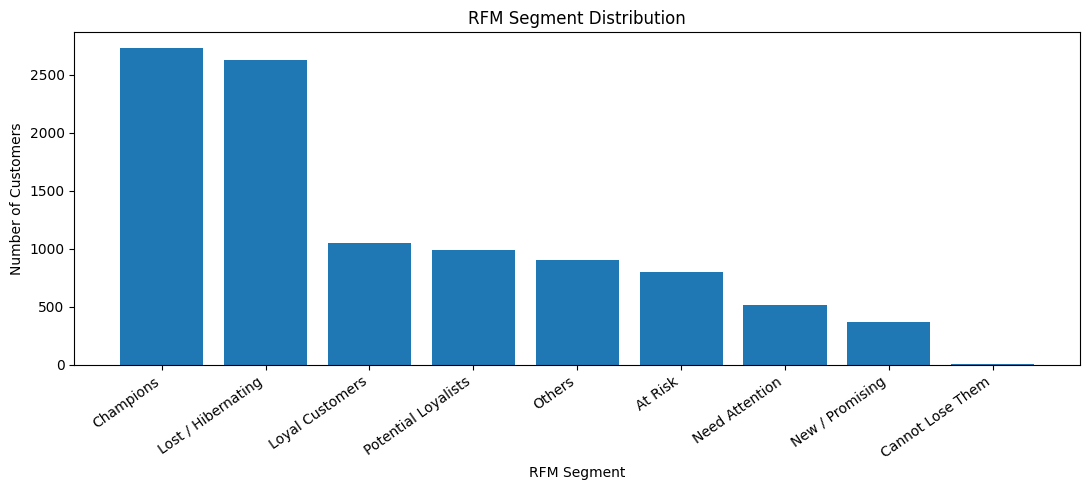

In [32]:
plot_data = rfm_summary.sort_values("customers", ascending=False)

plt.figure(figsize=(11, 5))
plt.bar(plot_data["rfm_segment"], plot_data["customers"])
plt.title("RFM Segment Distribution")
plt.xlabel("RFM Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=35, ha="right")
save_current_figure("fig_09_rfm_segment_distribution.png")
plt.show()

### Figure 2 — Revenue contribution by RFM segment

Saved: ../Module 4/figures\fig_10_rfm_revenue_contribution.png


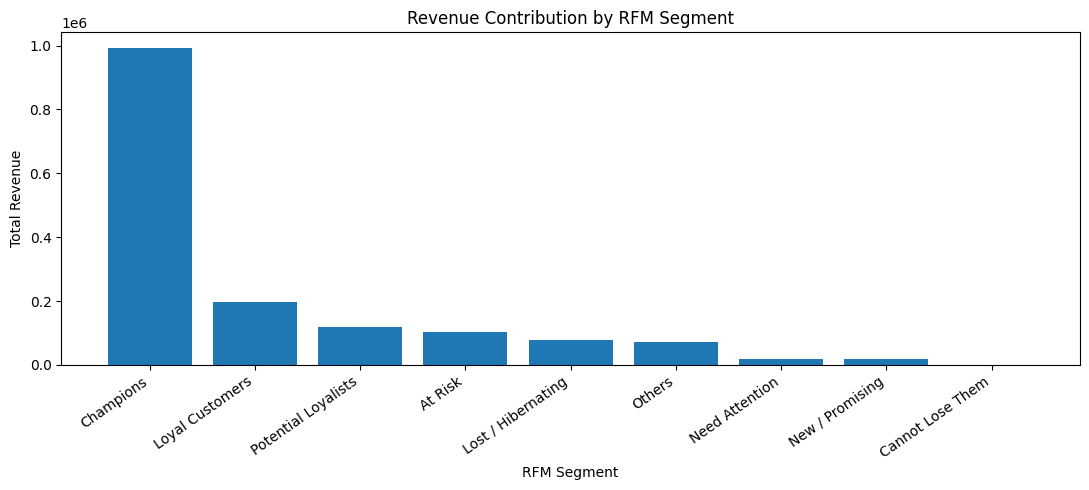

In [33]:
plot_data = rfm_summary.sort_values("total_revenue", ascending=False)

plt.figure(figsize=(11, 5))
plt.bar(plot_data["rfm_segment"], plot_data["total_revenue"])
plt.title("Revenue Contribution by RFM Segment")
plt.xlabel("RFM Segment")
plt.ylabel("Total Revenue")
plt.xticks(rotation=35, ha="right")
save_current_figure("fig_10_rfm_revenue_contribution.png")
plt.show()

## 4. Behavioral feature set for clustering

K-Means focuses on behavioral identity. RFM value columns are excluded from this behavioral clustering step so that RFM and K-Means remain two complementary lenses.

In [34]:
id_cols = [
    "customer_id", "profile_transaction_match", "last_order_date", "first_order_date",
    "rfm_code", "rfm_segment"
]

rfm_value_cols = [
    "recency", "frequency", "monetary", "R_score", "F_score", "M_score", "rfm_score",
    "monetary_per_order", "total_orders"
]

candidate_cols = [c for c in customer_features.columns if c not in id_cols + rfm_value_cols]

numeric_features = []
categorical_features = []

for c in candidate_cols:
    if customer_features[c].dtype in ["int64", "float64", "int32", "float32", "bool"]:
        numeric_features.append(c)
    elif customer_features[c].dtype == "object":
        categorical_features.append(c)

print("Numeric clustering features:", len(numeric_features))
print(numeric_features)

print("\nCategorical clustering features:", len(categorical_features))
print(categorical_features)

Numeric clustering features: 52
['expected_visits', 'actual_visits', 'visit_gap', 'visit_ratio', 'under_engaged_flag', 'customer_tenure_days', 'avg_order_value', 'median_order_value', 'max_order_value', 'avg_basket_size', 'median_basket_size', 'avg_unique_items_per_order', 'avg_categories_per_order', 'avg_item_price', 'avg_discount_pct', 'discount_order_rate', 'total_discount_amount_est', 'payment_share_card', 'payment_share_cash', 'payment_share_mobile', 'avg_order_hour', 'std_order_hour', 'weekend_order_rate', 'dow_share_friday', 'dow_share_monday', 'dow_share_saturday', 'dow_share_sunday', 'dow_share_thursday', 'dow_share_tuesday', 'dow_share_wednesday', 'meal_share_dinner', 'meal_share_late_night', 'meal_share_lunch', 'meal_share_morning', 'category_share_alcohol', 'category_share_appetizer', 'category_share_bakery', 'category_share_beverage', 'category_share_dessert', 'category_share_food', 'category_share_main', 'category_share_side', 'section_share_american', 'section_share_cafe

## 5. Preprocessing pipeline

In [35]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

try:
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])
except TypeError:
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse=False))
    ])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

X_behavior = preprocessor.fit_transform(customer_features)

print("Behavioral feature matrix shape:", X_behavior.shape)
print("Ready for K-Means clustering.")

Behavioral feature matrix shape: (10001, 551)
Ready for K-Means clustering.


## 6. K-Means model selection

K-Means is the main behavioral ML segmentation model. This section compares several values of K using inertia, silhouette score, Davies-Bouldin score, and Calinski-Harabasz score.

In [36]:
k_values = list(range(2, 11))
kmeans_results = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = model.fit_predict(X_behavior)

    sil = silhouette_score(X_behavior, labels)
    dbi = davies_bouldin_score(X_behavior, labels)
    ch = calinski_harabasz_score(X_behavior, labels)

    kmeans_results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": sil,
        "davies_bouldin": dbi,
        "calinski_harabasz": ch
    })

kmeans_results = pd.DataFrame(kmeans_results)
display(kmeans_results)

best_k = int(kmeans_results.loc[kmeans_results["silhouette"].idxmax(), "k"])
print("Best K by silhouette:", best_k)

,k,inertia,silhouette,davies_bouldin,calinski_harabasz
0,2,532988.004294,0.164194,2.061692,1297.500186
1,3,493605.765083,0.089857,2.531848,1099.284669
2,4,464432.638096,0.100905,2.511724,988.131607
3,5,446090.273682,0.100014,2.628738,874.248081
4,6,433909.441345,0.086506,2.553080,775.076762
5,7,424600.162326,0.088705,2.622643,696.511869
6,8,416849.504024,0.087907,2.628188,634.593224
7,9,409354.027477,0.066293,2.626367,588.249555
8,10,402415.934765,0.071618,2.608086,550.989967


Best K by silhouette: 2


### Figure 3 — Elbow curve

Saved: ../Module 4/figures\fig_11_kmeans_elbow_curve.png


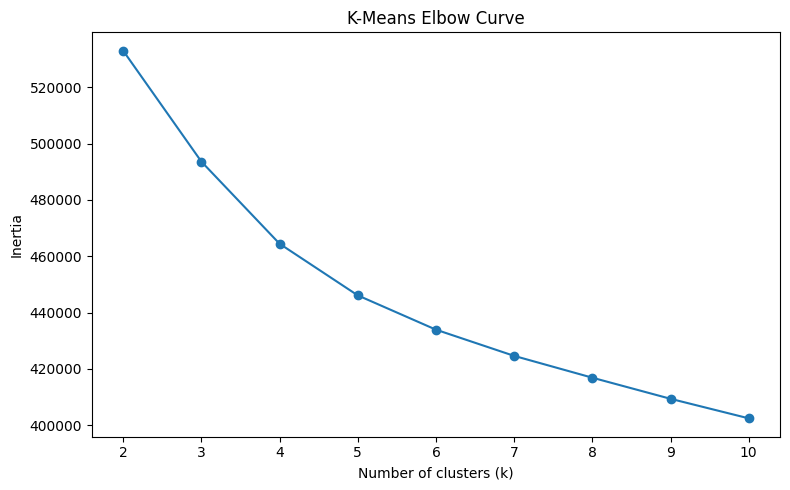

In [37]:
plt.figure(figsize=(8, 5))
plt.plot(kmeans_results["k"], kmeans_results["inertia"], marker="o")
plt.title("K-Means Elbow Curve")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.xticks(kmeans_results["k"])
save_current_figure("fig_11_kmeans_elbow_curve.png")
plt.show()

### Figure 4 — Silhouette score by K

Saved: ../Module 4/figures\fig_12_kmeans_silhouette_by_k.png


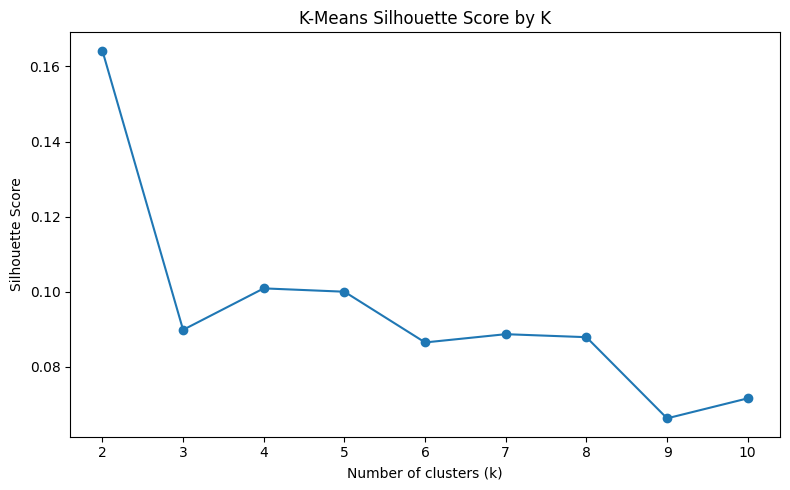

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(kmeans_results["k"], kmeans_results["silhouette"], marker="o")
plt.title("K-Means Silhouette Score by K")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(kmeans_results["k"])
save_current_figure("fig_12_kmeans_silhouette_by_k.png")
plt.show()

### Figure 5 — Davies-Bouldin score by K

Saved: ../Module 4/figures\fig_13_kmeans_davies_bouldin_by_k.png


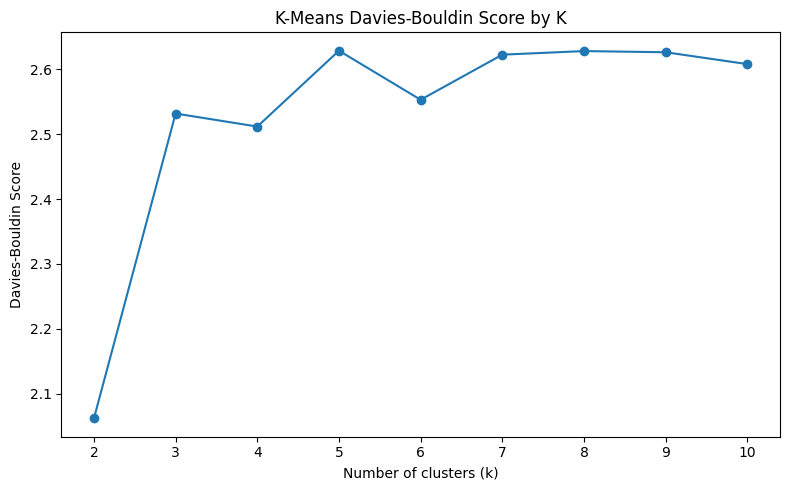

In [39]:
plt.figure(figsize=(8, 5))
plt.plot(kmeans_results["k"], kmeans_results["davies_bouldin"], marker="o")
plt.title("K-Means Davies-Bouldin Score by K")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Davies-Bouldin Score")
plt.xticks(kmeans_results["k"])
save_current_figure("fig_13_kmeans_davies_bouldin_by_k.png")
plt.show()

## 7. Gaussian Mixture Model (GMM) comparison

GMM is added as a probabilistic clustering alternative to K-Means. Unlike K-Means, which gives hard cluster assignments, GMM estimates the probability that each customer belongs to each cluster. This section tests whether a probabilistic model gives a better or more interpretable segmentation.


In [40]:
gmm_results_list = []

for k in k_values:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="diag",
        random_state=RANDOM_STATE,
        n_init=3,
        max_iter=300,
        reg_covar=1e-6
    )
    gmm_labels = gmm.fit_predict(X_behavior)

    gmm_results_list.append({
        "k": k,
        "bic": gmm.bic(X_behavior),
        "aic": gmm.aic(X_behavior),
        "silhouette": silhouette_score(X_behavior, gmm_labels),
        "davies_bouldin": davies_bouldin_score(X_behavior, gmm_labels),
        "calinski_harabasz": calinski_harabasz_score(X_behavior, gmm_labels)
    })

gmm_results = pd.DataFrame(gmm_results_list)
best_gmm_k_by_bic = int(gmm_results.loc[gmm_results["bic"].idxmin(), "k"])
best_gmm_k_by_silhouette = int(gmm_results.loc[gmm_results["silhouette"].idxmax(), "k"])

display(gmm_results)
print("Best GMM K by BIC:", best_gmm_k_by_bic)
print("Best GMM K by silhouette:", best_gmm_k_by_silhouette)


,k,bic,aic,silhouette,davies_bouldin,calinski_harabasz
0,2,-2.468928e+07,-2.470518e+07,0.003479,7.560936,128.162994
1,3,-2.662442e+07,-2.664827e+07,0.038815,5.398576,235.372642
2,4,-3.244481e+07,-3.247661e+07,-0.004859,6.111464,280.451698
3,5,-3.504274e+07,-3.508250e+07,0.001143,5.891668,265.343988
4,6,-3.651261e+07,-3.656033e+07,-0.036159,9.197526,157.453910
5,7,-3.823559e+07,-3.829126e+07,-0.053002,9.882740,104.800038
6,8,-3.942415e+07,-3.948777e+07,-0.045594,8.701064,142.541651
7,9,-4.015254e+07,-4.022411e+07,-0.032114,7.984810,164.873277
8,10,-4.031165e+07,-4.039118e+07,-0.036425,10.508463,163.780715


Best GMM K by BIC: 10
Best GMM K by silhouette: 3


### Figure 6 — GMM BIC / AIC by K

For GMM, BIC and AIC are useful because they penalize overly complex probabilistic models. Lower values are better.


Saved: ../Module 4/figures\fig_06_gmm_bic_aic_by_k.png


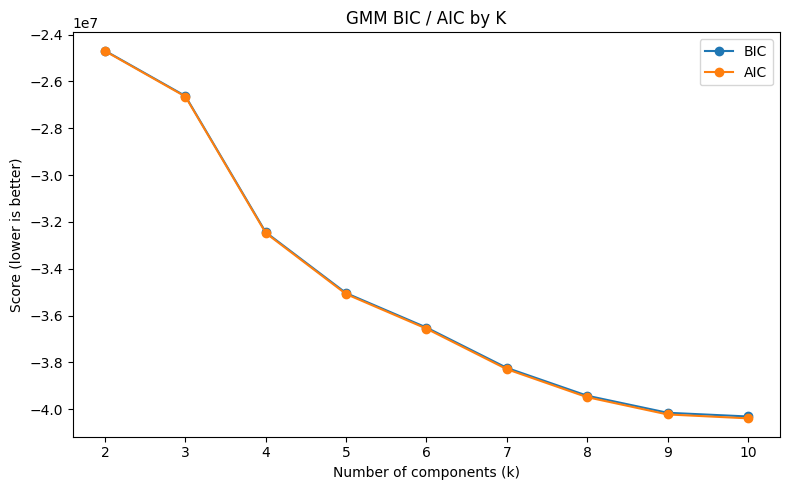

In [41]:
plt.figure(figsize=(8, 5))
plt.plot(gmm_results["k"], gmm_results["bic"], marker="o", label="BIC")
plt.plot(gmm_results["k"], gmm_results["aic"], marker="o", label="AIC")
plt.title("GMM BIC / AIC by K")
plt.xlabel("Number of components (k)")
plt.ylabel("Score (lower is better)")
plt.legend()
save_current_figure("fig_06_gmm_bic_aic_by_k.png")
plt.show()


### Figure 7 — GMM silhouette score by K

This checks whether GMM creates well-separated customer groups under hard cluster assignment.


Saved: ../Module 4/figures\fig_07_gmm_silhouette_by_k.png


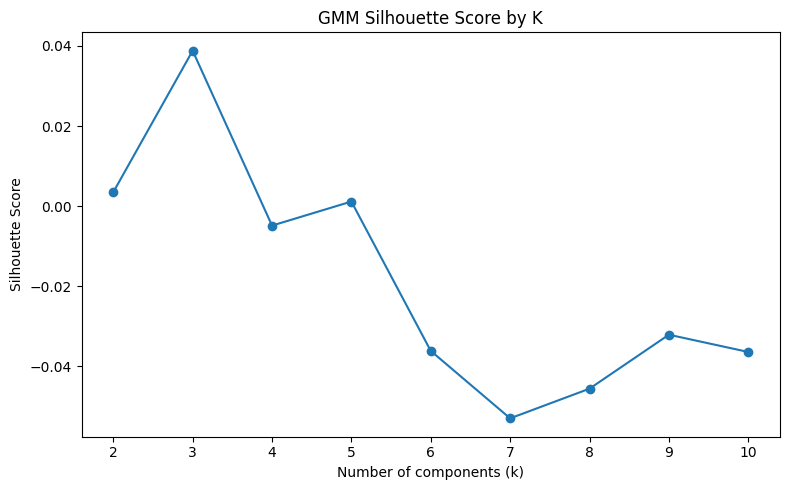

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(gmm_results["k"], gmm_results["silhouette"], marker="o")
plt.title("GMM Silhouette Score by K")
plt.xlabel("Number of components (k)")
plt.ylabel("Silhouette Score")
save_current_figure("fig_07_gmm_silhouette_by_k.png")
plt.show()


### K-Means vs GMM comparison at the selected business K

The final production clustering is still selected based on business interpretability. Here, GMM is trained with the same K as the final K-Means model so the two approaches can be compared fairly.


In [43]:
FINAL_BUSINESS_K = 5

gmm_model = GaussianMixture(
    n_components=FINAL_BUSINESS_K,
    covariance_type="diag",
    random_state=RANDOM_STATE,
    n_init=5,
    max_iter=300,
    reg_covar=1e-6
)
customer_features["gmm_cluster"] = gmm_model.fit_predict(X_behavior)

gmm_cluster_counts = customer_features["gmm_cluster"].value_counts().sort_index()
print("Final GMM components:", FINAL_BUSINESS_K)
display(gmm_cluster_counts.to_frame("customers"))

kmeans_row_at_business_k = kmeans_results.loc[kmeans_results["k"] == FINAL_BUSINESS_K].iloc[0]
gmm_row_at_business_k = gmm_results.loc[gmm_results["k"] == FINAL_BUSINESS_K].iloc[0]

clustering_model_comparison = pd.DataFrame([
    {
        "model": "K-Means",
        "k": FINAL_BUSINESS_K,
        "silhouette": kmeans_row_at_business_k["silhouette"],
        "davies_bouldin": kmeans_row_at_business_k["davies_bouldin"],
        "calinski_harabasz": kmeans_row_at_business_k["calinski_harabasz"],
        "bic": np.nan,
        "aic": np.nan,
        "assignment_type": "Hard assignment",
        "business_interpretability": "High"
    },
    {
        "model": "GMM",
        "k": FINAL_BUSINESS_K,
        "silhouette": gmm_row_at_business_k["silhouette"],
        "davies_bouldin": gmm_row_at_business_k["davies_bouldin"],
        "calinski_harabasz": gmm_row_at_business_k["calinski_harabasz"],
        "bic": gmm_row_at_business_k["bic"],
        "aic": gmm_row_at_business_k["aic"],
        "assignment_type": "Probabilistic assignment",
        "business_interpretability": "Medium"
    }
])

display(clustering_model_comparison)


Final GMM components: 5


,customers
0,942
1,4473
2,2722
3,935
4,929


,model,k,silhouette,davies_bouldin,calinski_harabasz,bic,aic,assignment_type,business_interpretability
0,K-Means,5,0.100014,2.628738,874.248081,NaN,NaN,Hard assignment,High
1,GMM,5,0.001143,5.891668,265.343988,-3.504274e+07,-3.508250e+07,Probabilistic assignment,Medium


### Figure 8 — GMM cluster size distribution

This plot checks whether the probabilistic alternative produces balanced usable customer groups.


Saved: ../Module 4/figures\fig_08_gmm_cluster_size_distribution.png


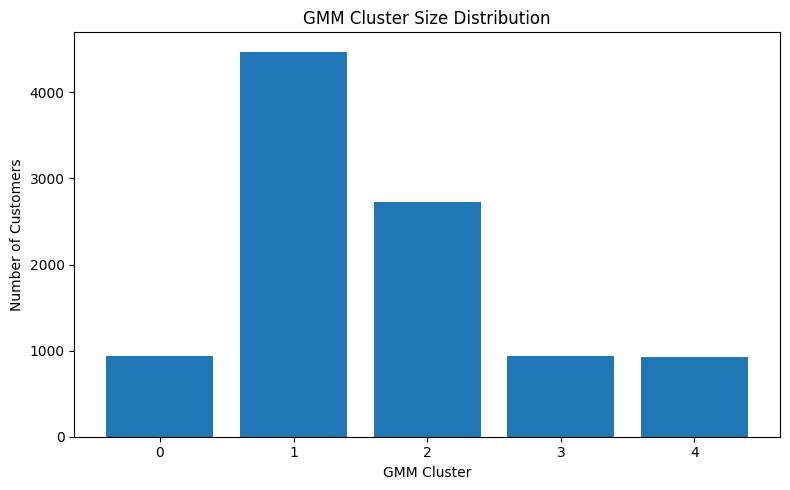

In [44]:
plt.figure(figsize=(8, 5))
plt.bar(gmm_cluster_counts.index.astype(str), gmm_cluster_counts.values)
plt.title("GMM Cluster Size Distribution")
plt.xlabel("GMM Cluster")
plt.ylabel("Number of Customers")
save_current_figure("fig_08_gmm_cluster_size_distribution.png")
plt.show()


### GMM decision note

GMM is kept as a comparison model, while K-Means remains the main behavioral clustering model because it is simpler to explain, easier to deploy, and more directly usable for business segment naming.


## 7. Train final K-Means model

By default, the notebook uses the best K by silhouette. You can manually override `N_CLUSTERS` if business interpretability suggests a different value.

In [45]:
N_CLUSTERS = 5  # Manual override: best business-oriented K; silhouette selected K=2

kmeans_model = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=50)
customer_features["kmeans_cluster"] = kmeans_model.fit_predict(X_behavior)

cluster_counts = customer_features["kmeans_cluster"].value_counts().sort_index()
print("Final K:", N_CLUSTERS)
display(cluster_counts.to_frame("customers"))

Final K: 5


,customers
0,2045
1,1926
2,1711
3,1741
4,2578


### Figure 6 — K-Means cluster size distribution

Saved: ../Module 4/figures\fig_14_kmeans_cluster_size_distribution.png


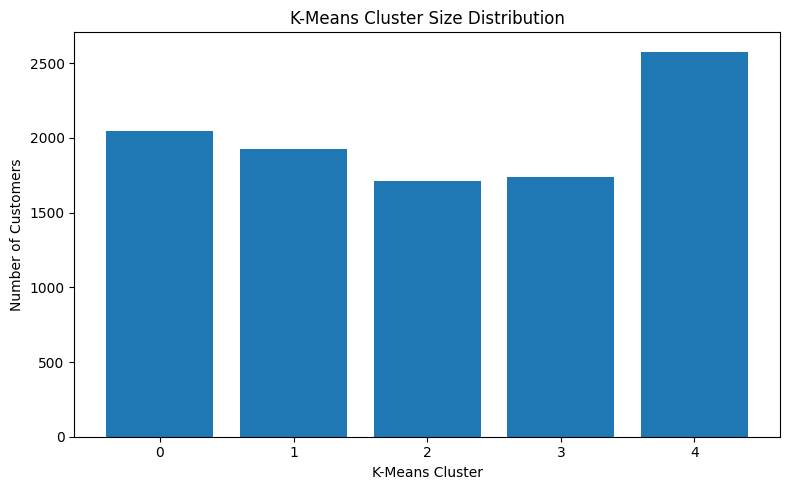

In [46]:
plt.figure(figsize=(8, 5))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)
plt.title("K-Means Cluster Size Distribution")
plt.xlabel("K-Means Cluster")
plt.ylabel("Number of Customers")
save_current_figure("fig_14_kmeans_cluster_size_distribution.png")
plt.show()

### Figure 7 — PCA visualization of K-Means clusters

Saved: ../Module 4/figures\fig_15_kmeans_pca_projection.png


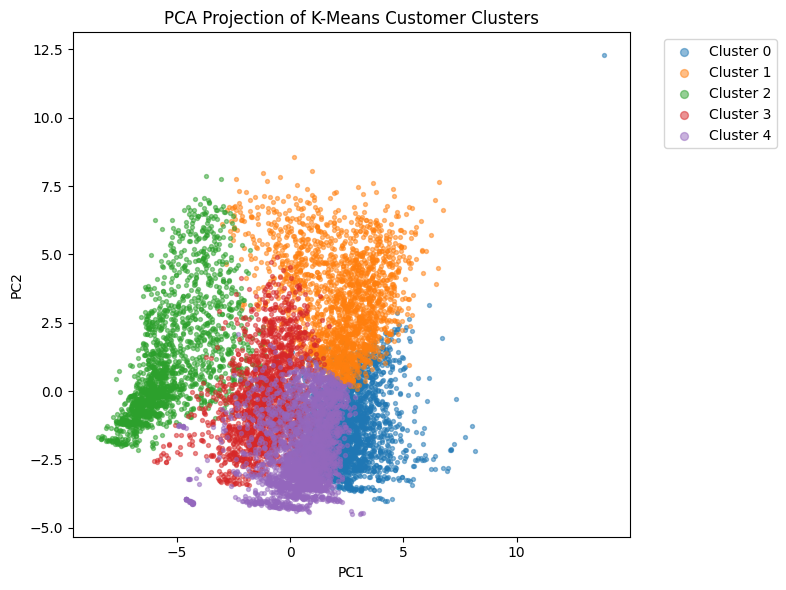

Explained variance by PC1 and PC2: [0.15164314 0.10706603]


In [47]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_behavior)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "kmeans_cluster": customer_features["kmeans_cluster"].astype(str)
})

plt.figure(figsize=(8, 6))
for cluster in sorted(pca_df["kmeans_cluster"].unique()):
    sub = pca_df[pca_df["kmeans_cluster"] == cluster]
    plt.scatter(sub["PC1"], sub["PC2"], s=8, alpha=0.5, label=f"Cluster {cluster}")

plt.title("PCA Projection of K-Means Customer Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(markerscale=2, bbox_to_anchor=(1.05, 1), loc="upper left")
save_current_figure("fig_15_kmeans_pca_projection.png")
plt.show()

print("Explained variance by PC1 and PC2:", pca.explained_variance_ratio_)

## 8. K-Means cluster profiling

In [48]:
kmeans_cluster_profiles = (
    customer_features
    .groupby("kmeans_cluster")
    .agg(
        customers=("customer_id", "count"),
        total_revenue=("monetary", "sum"),
        avg_monetary=("monetary", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_recency=("recency", "mean"),
        avg_order_value=("avg_order_value", "mean"),
        avg_basket_size=("avg_basket_size", "mean"),
        avg_discount_pct=("avg_discount_pct", "mean"),
        weekend_order_rate=("weekend_order_rate", "mean"),
        avg_visit_gap=("visit_gap", "mean")
    )
    .reset_index()
)

display(kmeans_cluster_profiles)

,kmeans_cluster,customers,total_revenue,avg_monetary,avg_frequency,avg_recency,avg_order_value,avg_basket_size,avg_discount_pct,weekend_order_rate,avg_visit_gap
0,0,2045,313976.06,153.533526,3.732518,492.617115,41.264632,3.432817,1.520418,0.355438,0.047433
1,1,1926,799481.66,415.099512,14.924714,77.794393,27.767473,2.858763,1.752363,0.338522,2.362409
2,2,1711,136495.49,79.775272,5.389831,363.705435,14.387011,2.815456,1.542152,0.341712,1.071303
3,3,1741,167268.01,96.075824,4.452613,408.651350,21.815259,2.830730,1.659479,0.290307,0.364159
4,4,2578,184660.57,71.629391,3.349108,523.879752,20.503406,2.236137,1.617120,0.341431,0.048487


### Figure 8 — K-Means cluster profile heatmap

Saved: ../Module 4/figures\fig_16_kmeans_cluster_profile_heatmap.png


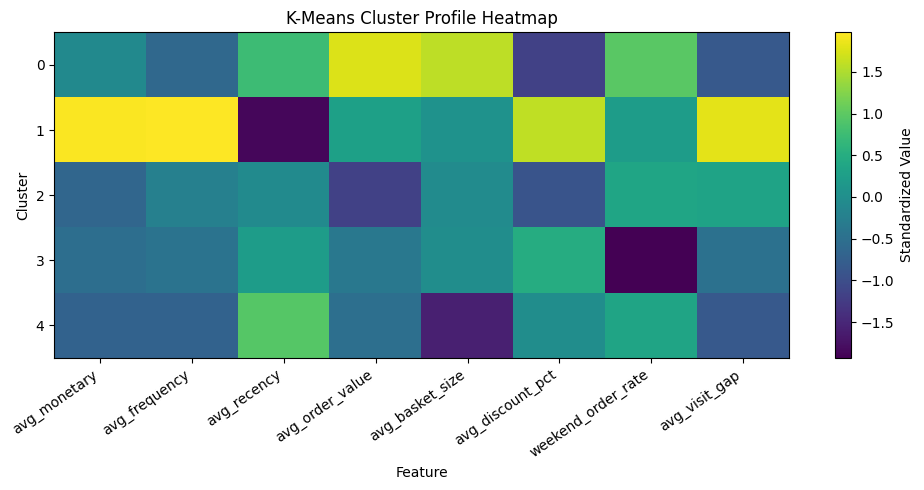

In [49]:
heatmap_cols = [
    "avg_monetary", "avg_frequency", "avg_recency", "avg_order_value",
    "avg_basket_size", "avg_discount_pct", "weekend_order_rate", "avg_visit_gap"
]
heatmap_data = kmeans_cluster_profiles.set_index("kmeans_cluster")[heatmap_cols]

heatmap_scaled = (heatmap_data - heatmap_data.mean()) / heatmap_data.std(ddof=0)
heatmap_scaled = heatmap_scaled.replace([np.inf, -np.inf], 0).fillna(0)

plt.figure(figsize=(10, 5))
plt.imshow(heatmap_scaled, aspect="auto")
plt.colorbar(label="Standardized Value")
plt.title("K-Means Cluster Profile Heatmap")
plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.xticks(range(len(heatmap_cols)), heatmap_cols, rotation=35, ha="right")
plt.yticks(range(len(heatmap_scaled.index)), heatmap_scaled.index)
save_current_figure("fig_16_kmeans_cluster_profile_heatmap.png")
plt.show()

## 9. Assign business names to K-Means clusters

In [50]:
def name_cluster(row):
    if row["avg_monetary"] >= kmeans_cluster_profiles["avg_monetary"].quantile(0.70):
        value = "High-Value"
    elif row["avg_monetary"] <= kmeans_cluster_profiles["avg_monetary"].quantile(0.30):
        value = "Low-Value"
    else:
        value = "Mid-Value"

    if row["avg_frequency"] >= kmeans_cluster_profiles["avg_frequency"].quantile(0.70):
        activity = "Frequent"
    elif row["avg_recency"] >= kmeans_cluster_profiles["avg_recency"].quantile(0.70):
        activity = "Inactive"
    else:
        activity = "Occasional"

    if row["avg_discount_pct"] >= kmeans_cluster_profiles["avg_discount_pct"].quantile(0.70):
        style = "Discount-Sensitive"
    elif row["avg_basket_size"] >= kmeans_cluster_profiles["avg_basket_size"].quantile(0.70):
        style = "Large-Basket"
    elif row["weekend_order_rate"] >= kmeans_cluster_profiles["weekend_order_rate"].quantile(0.70):
        style = "Weekend-Oriented"
    else:
        style = "Standard"

    return f"{value} {activity} {style}"

kmeans_cluster_profiles["kmeans_segment_name"] = kmeans_cluster_profiles.apply(name_cluster, axis=1)

name_map = dict(zip(kmeans_cluster_profiles["kmeans_cluster"], kmeans_cluster_profiles["kmeans_segment_name"]))
customer_features["kmeans_segment_name"] = customer_features["kmeans_cluster"].map(name_map)

display(kmeans_cluster_profiles[["kmeans_cluster", "kmeans_segment_name", "customers", "avg_monetary", "avg_frequency", "avg_recency", "avg_basket_size", "avg_discount_pct"]])

,kmeans_cluster,kmeans_segment_name,customers,avg_monetary,avg_frequency,avg_recency,avg_basket_size,avg_discount_pct
0,0,High-Value Inactive Large-Basket,2045,153.533526,3.732518,492.617115,3.432817,1.520418
1,1,High-Value Frequent Discount-Sensitive,1926,415.099512,14.924714,77.794393,2.858763,1.752363
2,2,Low-Value Frequent Weekend-Oriented,1711,79.775272,5.389831,363.705435,2.815456,1.542152
3,3,Mid-Value Occasional Discount-Sensitive,1741,96.075824,4.452613,408.651350,2.830730,1.659479
4,4,Low-Value Inactive Standard,2578,71.629391,3.349108,523.879752,2.236137,1.617120


## 10. Hierarchical clustering validation

Hierarchical clustering is used as a validation layer. It is not the main production model; it helps explain how the K-Means groups relate to each other.

Saved: ../Module 4/figures\fig_17_hierarchical_dendrogram_kmeans_centroids.png


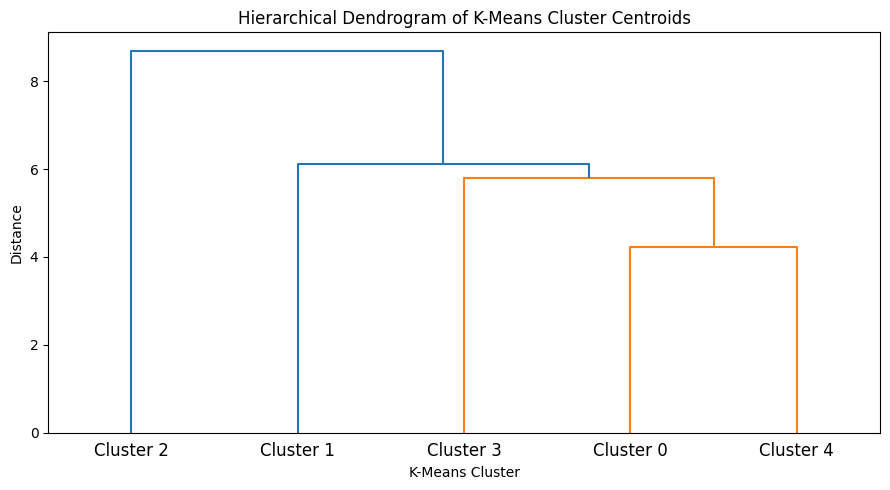

In [51]:
centroids = kmeans_model.cluster_centers_
centroid_linkage = linkage(centroids, method="ward")

plt.figure(figsize=(9, 5))
dendrogram(
    centroid_linkage,
    labels=[f"Cluster {i}" for i in range(N_CLUSTERS)]
)
plt.title("Hierarchical Dendrogram of K-Means Cluster Centroids")
plt.xlabel("K-Means Cluster")
plt.ylabel("Distance")
save_current_figure("fig_17_hierarchical_dendrogram_kmeans_centroids.png")
plt.show()

### Optional validation dendrogram on customer sample

Saved: ../Module 4/figures\fig_18_hierarchical_dendrogram_customer_sample.png


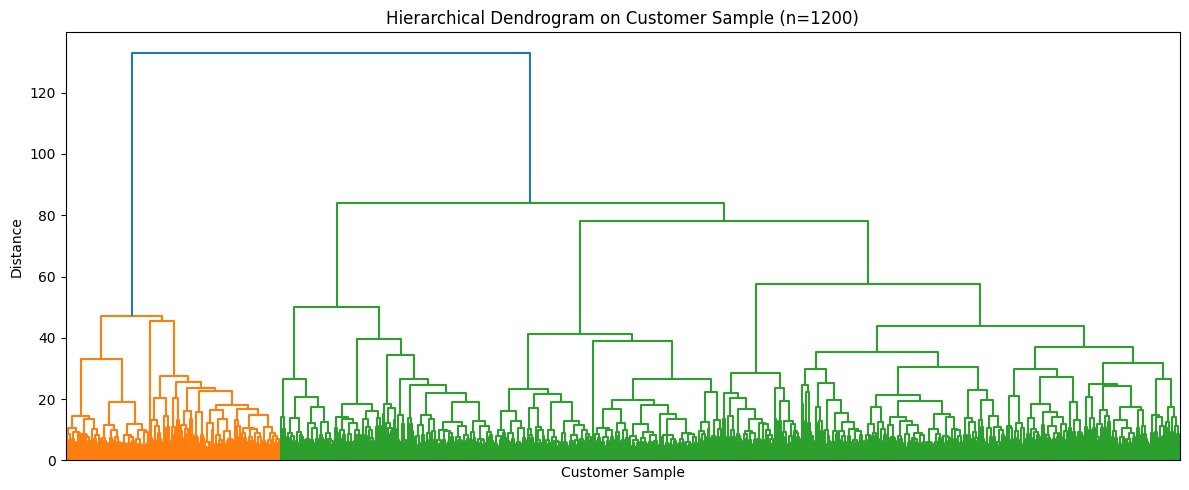

In [52]:
SAMPLE_SIZE = min(1200, X_behavior.shape[0])
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(X_behavior.shape[0], size=SAMPLE_SIZE, replace=False)
X_sample = X_behavior[sample_idx]

sample_linkage = linkage(X_sample, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(sample_linkage, no_labels=True, color_threshold=None)
plt.title(f"Hierarchical Dendrogram on Customer Sample (n={SAMPLE_SIZE})")
plt.xlabel("Customer Sample")
plt.ylabel("Distance")
save_current_figure("fig_18_hierarchical_dendrogram_customer_sample.png")
plt.show()

## 11. Hybrid RFM + behavioral segmentation

The hybrid segmentation combines customer value/lifecycle from RFM with customer behavior from K-Means. This is the final business-actionable segmentation layer.

In [53]:
def assign_value_tier(score):
    if score >= 12:
        return "High-Value"
    elif score >= 8:
        return "Mid-Value"
    elif score > 0:
        return "Low-Value"
    else:
        return "No-History"

customer_features["rfm_value_tier"] = customer_features["rfm_score"].apply(assign_value_tier)

customer_features["hybrid_segment"] = (
    customer_features["rfm_value_tier"].astype(str)
    + " | "
    + customer_features["kmeans_segment_name"].astype(str)
)

hybrid_profiles = (
    customer_features
    .groupby("hybrid_segment")
    .agg(
        customers=("customer_id", "count"),
        total_revenue=("monetary", "sum"),
        avg_monetary=("monetary", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_recency=("recency", "mean"),
        avg_order_value=("avg_order_value", "mean"),
        avg_basket_size=("avg_basket_size", "mean"),
        avg_discount_pct=("avg_discount_pct", "mean"),
        avg_visit_gap=("visit_gap", "mean")
    )
    .sort_values(["total_revenue", "customers"], ascending=False)
    .reset_index()
)

display(hybrid_profiles.head(20))
print("Number of hybrid segments:", hybrid_profiles.shape[0])

,hybrid_segment,customers,total_revenue,avg_monetary,avg_frequency,avg_recency,avg_order_value,avg_basket_size,avg_discount_pct,avg_visit_gap
0,High-Value | High-Value Frequent Discount-Sens...,1834,783385.19,427.145687,15.310251,68.500000,27.953483,2.858489,1.654367,2.378408
1,Mid-Value | High-Value Inactive Large-Basket,828,130844.26,158.024469,4.131643,383.049517,39.562305,3.297430,1.340870,0.033816
2,High-Value | High-Value Inactive Large-Basket,345,126572.71,366.877420,8.200000,136.785507,41.483911,3.336006,1.323231,0.182609
3,Mid-Value | Low-Value Inactive Standard,784,84132.41,107.311747,4.825255,307.751276,22.575996,2.386502,1.401652,0.096939
4,High-Value | Low-Value Frequent Weekend-Oriented,446,80521.21,180.540830,11.793722,49.291480,15.508079,2.840886,1.457863,3.322870
5,High-Value | Mid-Value Occasional Discount-Sen...,362,77694.33,214.625221,9.754144,78.024862,22.401746,2.825167,1.591082,0.972376
6,Mid-Value | Mid-Value Occasional Discount-Sens...,596,60857.09,102.109211,4.738255,270.697987,22.140998,2.857534,1.594964,0.387584
7,Low-Value | High-Value Inactive Large-Basket,872,56559.09,64.861342,1.586009,737.438073,42.794305,3.599675,1.768922,0.006881
8,Low-Value | Low-Value Inactive Standard,1551,53473.44,34.476750,1.738233,696.038040,19.202460,2.146346,1.797711,0.021921
9,High-Value | Low-Value Inactive Standard,243,47054.72,193.640823,8.868313,122.345679,22.120093,2.324115,1.159628,0.061728


Number of hybrid segments: 15


### Figure 9 — Top hybrid segments by customer count

Saved: ../Module 4/figures\fig_19_top_hybrid_segments_by_count.png


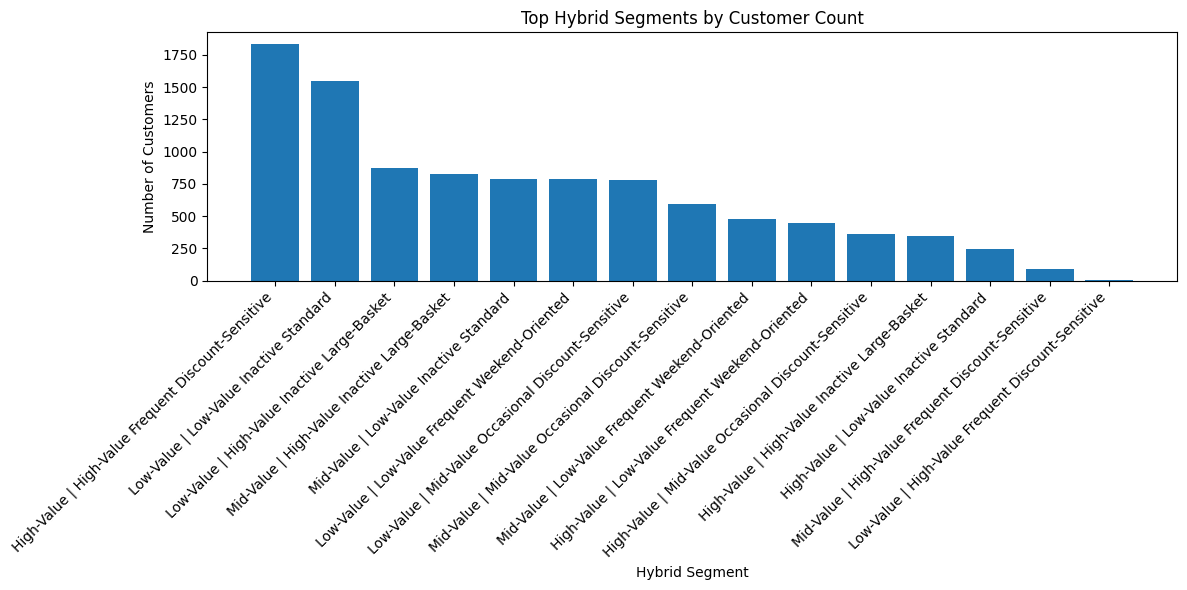

In [54]:
top_hybrid_count = hybrid_profiles.sort_values("customers", ascending=False).head(15)

plt.figure(figsize=(12, 6))
plt.bar(top_hybrid_count["hybrid_segment"], top_hybrid_count["customers"])
plt.title("Top Hybrid Segments by Customer Count")
plt.xlabel("Hybrid Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45, ha="right")
save_current_figure("fig_19_top_hybrid_segments_by_count.png")
plt.show()

### Figure 10 — Top hybrid segments by revenue

Saved: ../Module 4/figures\fig_20_top_hybrid_segments_by_revenue.png


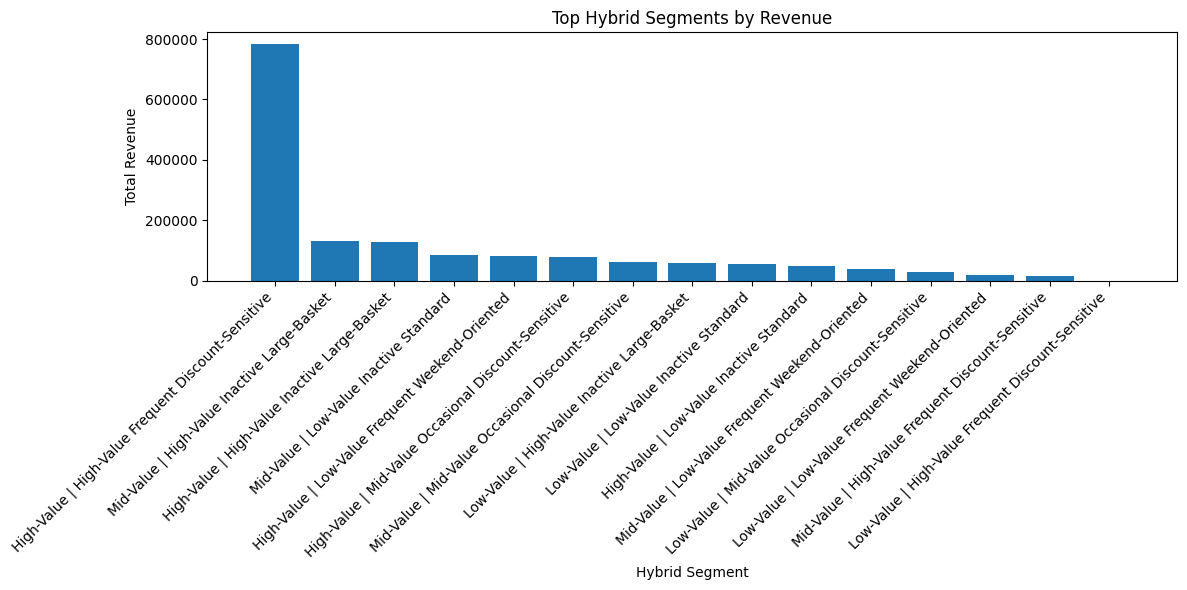

In [55]:
top_hybrid_revenue = hybrid_profiles.sort_values("total_revenue", ascending=False).head(15)

plt.figure(figsize=(12, 6))
plt.bar(top_hybrid_revenue["hybrid_segment"], top_hybrid_revenue["total_revenue"])
plt.title("Top Hybrid Segments by Revenue")
plt.xlabel("Hybrid Segment")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45, ha="right")
save_current_figure("fig_20_top_hybrid_segments_by_revenue.png")
plt.show()

## 12. Strategic action mapping

In [56]:
def recommend_action(row):
    segment = row["hybrid_segment"].lower()

    if "high-value" in segment and row["avg_recency"] <= customer_features["recency"].median():
        return "VIP loyalty program and premium personalization"
    if "high-value" in segment and row["avg_recency"] > customer_features["recency"].median():
        return "Win-back campaign for valuable customers"
    if "discount" in segment:
        return "Targeted promotions and coupon campaigns"
    if row["avg_visit_gap"] > customer_features["visit_gap"].quantile(0.75):
        return "Reactivation campaign based on visit gap"
    if row["avg_basket_size"] > customer_features["avg_basket_size"].quantile(0.75):
        return "Bundle and cross-sell offers"
    if "low-value" in segment:
        return "Low-cost engagement campaign"
    return "Standard personalized communication"

hybrid_profiles["recommended_action"] = hybrid_profiles.apply(recommend_action, axis=1)

display(hybrid_profiles[[
    "hybrid_segment", "customers", "total_revenue", "avg_recency",
    "avg_frequency", "avg_basket_size", "avg_discount_pct", "avg_visit_gap",
    "recommended_action"
]].head(25))

,hybrid_segment,customers,total_revenue,avg_recency,avg_frequency,avg_basket_size,avg_discount_pct,avg_visit_gap,recommended_action
0,High-Value | High-Value Frequent Discount-Sens...,1834,783385.19,68.500000,15.310251,2.858489,1.654367,2.378408,VIP loyalty program and premium personalization
1,Mid-Value | High-Value Inactive Large-Basket,828,130844.26,383.049517,4.131643,3.297430,1.340870,0.033816,Win-back campaign for valuable customers
2,High-Value | High-Value Inactive Large-Basket,345,126572.71,136.785507,8.200000,3.336006,1.323231,0.182609,VIP loyalty program and premium personalization
3,Mid-Value | Low-Value Inactive Standard,784,84132.41,307.751276,4.825255,2.386502,1.401652,0.096939,Reactivation campaign based on visit gap
4,High-Value | Low-Value Frequent Weekend-Oriented,446,80521.21,49.291480,11.793722,2.840886,1.457863,3.322870,VIP loyalty program and premium personalization
5,High-Value | Mid-Value Occasional Discount-Sen...,362,77694.33,78.024862,9.754144,2.825167,1.591082,0.972376,VIP loyalty program and premium personalization
6,Mid-Value | Mid-Value Occasional Discount-Sens...,596,60857.09,270.697987,4.738255,2.857534,1.594964,0.387584,Targeted promotions and coupon campaigns
7,Low-Value | High-Value Inactive Large-Basket,872,56559.09,737.438073,1.586009,3.599675,1.768922,0.006881,Win-back campaign for valuable customers
8,Low-Value | Low-Value Inactive Standard,1551,53473.44,696.038040,1.738233,2.146346,1.797711,0.021921,Reactivation campaign based on visit gap
9,High-Value | Low-Value Inactive Standard,243,47054.72,122.345679,8.868313,2.324115,1.159628,0.061728,VIP loyalty program and premium personalization


## 13. Model comparison summary

In [57]:
model_comparison = pd.DataFrame([
    {
        "approach": "RFM rule-based segmentation",
        "role": "Business baseline",
        "main_question": "How valuable and active is the customer?",
        "output": "rfm_segment",
        "production_use": "Lifecycle, loyalty, churn priority",
        "limitation": "Does not capture preferences or detailed behavior"
    },
    {
        "approach": "K-Means clustering",
        "role": "Main behavioral ML model",
        "main_question": "What natural behavioral group does the customer belong to?",
        "output": "kmeans_cluster / kmeans_segment_name",
        "production_use": "Behavioral personalization and targeting",
        "limitation": "Cluster IDs need profiling and interpretation"
    },
    {
        "approach": "Hierarchical clustering",
        "role": "Validation and explainability",
        "main_question": "Are the behavioral groups structurally meaningful?",
        "output": "Dendrograms / hierarchy",
        "production_use": "Report validation and cluster explanation",
        "limitation": "Not used as main production model"
    },
    {
        "approach": "Hybrid RFM + behavioral segmentation",
        "role": "Final business segmentation",
        "main_question": "What action should the business take for each customer?",
        "output": "hybrid_segment",
        "production_use": "Campaigns, dashboards, Module 5 assistant insights",
        "limitation": "Requires clear business naming and playbook"
    },
])

display(model_comparison)

,approach,role,main_question,output,production_use,limitation
0,RFM rule-based segmentation,Business baseline,How valuable and active is the customer?,rfm_segment,"Lifecycle, loyalty, churn priority",Does not capture preferences or detailed behavior
1,K-Means clustering,Main behavioral ML model,What natural behavioral group does the custome...,kmeans_cluster / kmeans_segment_name,Behavioral personalization and targeting,Cluster IDs need profiling and interpretation
2,Hierarchical clustering,Validation and explainability,Are the behavioral groups structurally meaning...,Dendrograms / hierarchy,Report validation and cluster explanation,Not used as main production model
3,Hybrid RFM + behavioral segmentation,Final business segmentation,What action should the business take for each ...,hybrid_segment,"Campaigns, dashboards, Module 5 assistant insi...",Requires clear business naming and playbook


## 14. Save Notebook 2 outputs

In [58]:
segments_path = os.path.join(OUTPUT_DIR, "customer_segments_model_outputs.csv")
rfm_summary_path = os.path.join(OUTPUT_DIR, "rfm_segment_summary.csv")
kmeans_profiles_path = os.path.join(OUTPUT_DIR, "kmeans_cluster_profiles.csv")
hybrid_profiles_path = os.path.join(OUTPUT_DIR, "hybrid_segment_profiles.csv")
model_comparison_path = os.path.join(OUTPUT_DIR, "model_comparison_report.csv")
gmm_results_path = os.path.join(OUTPUT_DIR, "gmm_model_selection_results.csv")
clustering_comparison_path = os.path.join(OUTPUT_DIR, "clustering_model_comparison.csv")

customer_features.to_csv(segments_path, index=False)
rfm_summary.to_csv(rfm_summary_path, index=False)
kmeans_cluster_profiles.to_csv(kmeans_profiles_path, index=False)
hybrid_profiles.to_csv(hybrid_profiles_path, index=False)
model_comparison.to_csv(model_comparison_path, index=False)
gmm_results.to_csv(gmm_results_path, index=False)
clustering_model_comparison.to_csv(clustering_comparison_path, index=False)

preprocessor_path = os.path.join(MODEL_DIR, "behavior_preprocessor.pkl")
kmeans_model_path = os.path.join(MODEL_DIR, "kmeans_model.pkl")
pca_model_path = os.path.join(MODEL_DIR, "pca_model.pkl")
gmm_model_path = os.path.join(MODEL_DIR, "gmm_model.pkl")

joblib.dump(preprocessor, preprocessor_path)
joblib.dump(kmeans_model, kmeans_model_path)
joblib.dump(pca, pca_model_path)
joblib.dump(gmm_model, gmm_model_path)

rfm_rules = {
    "description": "RFM segment rules based on R_score, F_score, M_score, and rfm_score.",
    "segments": sorted(customer_features["rfm_segment"].dropna().unique().tolist()),
    "value_tier_rules": {
        "High-Value": "rfm_score >= 12",
        "Mid-Value": "8 <= rfm_score < 12",
        "Low-Value": "0 < rfm_score < 8",
        "No-History": "rfm_score == 0"
    }
}

rfm_rules_path = os.path.join(MODEL_DIR, "rfm_segment_rules.json")
with open(rfm_rules_path, "w") as f:
    json.dump(rfm_rules, f, indent=2)

hybrid_mapping_path = os.path.join(MODEL_DIR, "hybrid_segment_mapping.json")
hybrid_mapping = {
    "kmeans_name_map": {str(k): v for k, v in name_map.items()},
    "hybrid_segments": sorted(customer_features["hybrid_segment"].dropna().unique().tolist())
}
with open(hybrid_mapping_path, "w") as f:
    json.dump(hybrid_mapping, f, indent=2)

summary = {
    "n_customers": int(customer_features.shape[0]),
    "n_features_after_modeling": int(customer_features.shape[1]),
    "n_rfm_segments": int(customer_features["rfm_segment"].nunique()),
    "n_kmeans_clusters_final": int(N_CLUSTERS),
    "n_gmm_components_final": int(FINAL_BUSINESS_K),
    "n_hybrid_segments": int(customer_features["hybrid_segment"].nunique()),
    "best_k_by_silhouette": int(best_k),
    "best_gmm_k_by_bic": int(best_gmm_k_by_bic),
    "best_gmm_k_by_silhouette": int(best_gmm_k_by_silhouette),
    "k_selection_note": "Silhouette selected K=2, but final K=5 was manually selected for better business interpretability and actionable segmentation.",
    "outputs": {
        "customer_segments": segments_path,
        "rfm_summary": rfm_summary_path,
        "kmeans_profiles": kmeans_profiles_path,
        "hybrid_profiles": hybrid_profiles_path,
        "model_comparison": model_comparison_path,
        "gmm_results": gmm_results_path,
        "clustering_comparison": clustering_comparison_path
    },
    "models": {
        "preprocessor": preprocessor_path,
        "kmeans": kmeans_model_path,
        "pca": pca_model_path,
        "gmm": gmm_model_path,
        "rfm_rules": rfm_rules_path,
        "hybrid_mapping": hybrid_mapping_path
    }
}

summary_path = os.path.join(OUTPUT_DIR, "notebook2_segmentation_summary.json")
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("Saved customer segments:", segments_path)
print("Saved RFM summary:", rfm_summary_path)
print("Saved K-Means profiles:", kmeans_profiles_path)
print("Saved hybrid profiles:", hybrid_profiles_path)
print("Saved model comparison:", model_comparison_path)
print("Saved GMM results:", gmm_results_path)
print("Saved clustering comparison:", clustering_comparison_path)
print("Saved summary JSON:", summary_path)
print("Saved model artifacts in:", MODEL_DIR)

Saved customer segments: ../Module 4\customer_segments_model_outputs.csv
Saved RFM summary: ../Module 4\rfm_segment_summary.csv
Saved K-Means profiles: ../Module 4\kmeans_cluster_profiles.csv
Saved hybrid profiles: ../Module 4\hybrid_segment_profiles.csv
Saved model comparison: ../Module 4\model_comparison_report.csv
Saved GMM results: ../Module 4\gmm_model_selection_results.csv
Saved clustering comparison: ../Module 4\clustering_model_comparison.csv
Saved summary JSON: ../Module 4\notebook2_segmentation_summary.json
Saved model artifacts in: ../Module 4/models


## 15. Final check for Notebook 3

In [59]:
print("Final segmentation output shape:", customer_features.shape)
print("Unique customers:", customer_features["customer_id"].nunique())
print("RFM segments:", customer_features["rfm_segment"].nunique())
print("K-Means clusters:", customer_features["kmeans_cluster"].nunique())
print("Hybrid segments:", customer_features["hybrid_segment"].nunique())

display(customer_features[[
    "customer_id", "rfm_segment", "rfm_value_tier",
    "kmeans_cluster", "kmeans_segment_name", "hybrid_segment"
]].head())

print("\nFigure files created by Notebook 2:")
for fig_name in sorted(os.listdir(FIGURE_DIR)):
    if fig_name.startswith("fig_09") or fig_name.startswith("fig_1") or fig_name.startswith("fig_20"):
        print(fig_name)

Final segmentation output shape: (10001, 84)
Unique customers: 10001
RFM segments: 9
K-Means clusters: 5
Hybrid segments: 15


,customer_id,rfm_segment,rfm_value_tier,kmeans_cluster,kmeans_segment_name,hybrid_segment
0,5485,New / Promising,Mid-Value,0,High-Value Inactive Large-Basket,Mid-Value | High-Value Inactive Large-Basket
1,7761,Potential Loyalists,Mid-Value,0,High-Value Inactive Large-Basket,Mid-Value | High-Value Inactive Large-Basket
2,1774,At Risk,Mid-Value,3,Mid-Value Occasional Discount-Sensitive,Mid-Value | Mid-Value Occasional Discount-Sens...
3,3417,Potential Loyalists,Mid-Value,0,High-Value Inactive Large-Basket,Mid-Value | High-Value Inactive Large-Basket
4,447,Champions,High-Value,2,Low-Value Frequent Weekend-Oriented,High-Value | Low-Value Frequent Weekend-Oriented



Figure files created by Notebook 2:
fig_09_orders_by_day_of_week.png
fig_09_rfm_segment_distribution.png
fig_10_revenue_by_section.png
fig_10_rfm_revenue_contribution.png
fig_11_kmeans_elbow_curve.png
fig_11_revenue_by_category.png
fig_12_customer_feature_correlation_heatmap.png
fig_12_kmeans_silhouette_by_k.png
fig_13_kmeans_davies_bouldin_by_k.png
fig_14_kmeans_cluster_size_distribution.png
fig_15_kmeans_pca_projection.png
fig_16_kmeans_cluster_profile_heatmap.png
fig_17_hierarchical_dendrogram_kmeans_centroids.png
fig_18_hierarchical_dendrogram_customer_sample.png
fig_19_top_hybrid_segments_by_count.png
fig_20_top_hybrid_segments_by_revenue.png
